In [1]:
import re
import pandas as pd
from itertools import combinations
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import itertools
import tracemalloc
import time
from collections import Counter
import matplotlib.ticker as ticker
import random

/Users/bercaakbayir/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from src.helper import kaggle_data_handler, print_results, generate_association_rules
from src.algorithms import (triangular_matrix_method, triples_method, 
                            apriori, multihash_algorithm, son_algorithm, son_mapreduce)

In [3]:
kaggle_link = 'https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows'

In [4]:
df = kaggle_data_handler(kaggle_link)

In [5]:
df

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,https://m.media-amazon.com/images/M/MV5BNGEwMT...,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,A young New York socialite becomes interested ...,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,NaN
996,https://m.media-amazon.com/images/M/MV5BODk3Yj...,Giant,1956,G,201 min,"Drama, Western",7.6,Sprawling epic covering the life of a Texas ca...,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,NaN
997,https://m.media-amazon.com/images/M/MV5BM2U3Yz...,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,"In Hawaii in 1941, a private is cruelly punish...",85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,"30,500,000"
998,https://m.media-amazon.com/images/M/MV5BZTBmMj...,Lifeboat,1944,NaN,97 min,"Drama, War",7.6,Several survivors of a torpedoed merchant ship...,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,NaN


In [6]:
df.describe()

,IMDB_Rating,Meta_score,No_of_Votes
count,1000.000000,843.000000,1.000000e+03
mean,7.949300,77.971530,2.736929e+05
std,0.275491,12.376099,3.273727e+05
min,7.600000,28.000000,2.508800e+04
25%,7.700000,70.000000,5.552625e+04
50%,7.900000,79.000000,1.385485e+05
75%,8.100000,87.000000,3.741612e+05
max,9.300000,100.000000,2.343110e+06


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [8]:
df.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='object')

# Defining the Baskets & Items

In [9]:
df.isnull().sum() / len(df) * 100

Poster_Link       0.0
Series_Title      0.0
Released_Year     0.0
Certificate      10.1
Runtime           0.0
Genre             0.0
IMDB_Rating       0.0
Overview          0.0
Meta_score       15.7
Director          0.0
Star1             0.0
Star2             0.0
Star3             0.0
Star4             0.0
No_of_Votes       0.0
Gross            16.9
dtype: float64

In [10]:
PROPORTION = 1.0 # Sampling Global Variable

In [11]:
def sample_baskets(df, proportion):
    basket_def = df[["Star1","Star2","Star3","Star4"]].values.tolist()
    basket_def = [set(row) for row in basket_def]
    
    sample_size = int(len(basket_def) * proportion)
    
    sampled_baskets = random.sample(basket_def, sample_size)
        
    return sampled_baskets

    

In [12]:
baskets = sample_baskets(df, PROPORTION)
len(baskets)

1000

# Basket Data Analysis

In [13]:
def normalize_name(name: str) -> str:
    name = name.strip()
    name = re.sub(r'\s+', ' ', name)         
    name = name.title()                       
    name = re.sub(r"'([A-Z])", lambda m: "'" + m.group(1), name)
    return name


def normalize_baskets(baskets: list[set]) -> list[set]:
    return [
        {normalize_name(actor) for actor in basket}
        for basket in baskets
    ]

In [14]:
baskets = normalize_baskets(baskets)

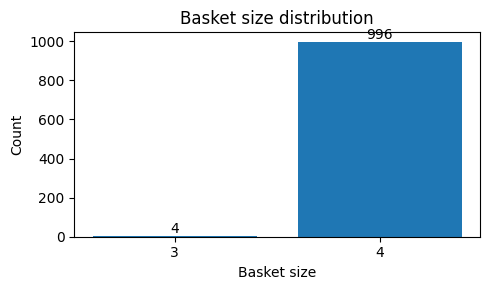

In [15]:
sizes = [len(b) for b in baskets]
counts = Counter(sizes)

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(counts.keys(), counts.values())
ax.bar_label(bars) 
ax.set_xlabel('Basket size')
ax.set_ylabel('Count')
ax.set_title('Basket size distribution')
ax.set_xticks(list(counts.keys()))
plt.tight_layout()
plt.show()

# Support for Singletons

In [16]:
singleton_support = defaultdict(int)

for basket in baskets:
    for item in basket:
        singleton_support[item] += 1

singleton_support = dict(sorted(singleton_support.items(), key=lambda x: x[1], reverse=True))

print("Singleton Support:")
for item, support in singleton_support.items():
    print(f"  {item}: {support}")

Singleton Support:
  Robert De Niro: 17
  Tom Hanks: 14
  Al Pacino: 13
  Brad Pitt: 12
  Clint Eastwood: 12
  Matt Damon: 11
  Christian Bale: 11
  Leonardo Dicaprio: 11
  James Stewart: 10
  Scarlett Johansson: 9
  Denzel Washington: 9
  Michael Caine: 9
  Humphrey Bogart: 9
  Ethan Hawke: 9
  Johnny Depp: 9
  Harrison Ford: 8
  Aamir Khan: 8
  Toshirô Mifune: 7
  Robert Downey Jr.: 7
  Cary Grant: 7
  Edward Norton: 7
  Ian Mckellen: 7
  Morgan Freeman: 7
  Tom Cruise: 7
  Emma Watson: 7
  Russell Crowe: 7
  Mark Ruffalo: 7
  Jeff Bridges: 7
  Jake Gyllenhaal: 7
  Bruce Willis: 7
  William Holden: 6
  John Wayne: 6
  Joe Pesci: 6
  Chris Evans: 6
  Christopher Plummer: 6
  Katharine Hepburn: 6
  Diane Keaton: 6
  Julianne Moore: 6
  Shah Rukh Khan: 6
  Philip Seymour Hoffman: 6
  Matthew Mcconaughey: 6
  Bill Murray: 6
  Daniel Radcliffe: 6
  Rupert Grint: 6
  Tatsuya Nakadai: 6
  Sean Penn: 6
  Ed Harris: 6
  Rachel Mcadams: 6
  Gene Hackman: 6
  Paul Newman: 6
  Dustin Hoffman: 6


# Support for Doubletons

In [17]:
doubleton_support = defaultdict(int)

for basket in baskets:
    for pair in combinations(sorted(basket), 2):
        doubleton_support[pair] += 1

doubleton_support = dict(sorted(doubleton_support.items(), key=lambda x: x[1], reverse=True))

print("Doubleton Support:")
for pair, support in doubleton_support.items():
    print(f"  {pair}: {support}")

Doubleton Support:
  ('Daniel Radcliffe', 'Rupert Grint'): 6
  ('Daniel Radcliffe', 'Emma Watson'): 5
  ('Emma Watson', 'Rupert Grint'): 5
  ('Joe Pesci', 'Robert De Niro'): 4
  ('Tim Allen', 'Tom Hanks'): 4
  ('Takashi Shimura', 'Toshirô Mifune'): 3
  ('Chris Evans', 'Joe Russo'): 3
  ('Chris Evans', 'Robert Downey Jr.'): 3
  ('Chris Evans', 'Scarlett Johansson'): 3
  ('Joe Russo', 'Robert Downey Jr.'): 3
  ('Diane Keaton', 'Woody Allen'): 3
  ('Christian Bale', 'Michael Caine'): 3
  ('Humphrey Bogart', 'Lauren Bacall'): 3
  ('Elijah Wood', 'Ian Mckellen'): 3
  ('Elijah Wood', 'Orlando Bloom'): 3
  ('Ian Mckellen', 'Orlando Bloom'): 3
  ('Carrie Fisher', 'Harrison Ford'): 3
  ('Carrie Fisher', 'Mark Hamill'): 3
  ('Harrison Ford', 'Mark Hamill'): 3
  ('Al Pacino', 'Robert De Niro'): 3
  ('Tatsuya Nakadai', 'Toshirô Mifune'): 3
  ('Al Pacino', 'Diane Keaton'): 3
  ('Ethan Hawke', 'Julie Delpy'): 3
  ('Mark Ruffalo', 'Robert Downey Jr.'): 3
  ('Ethan Coen', 'John Turturro'): 3
  ('Joan 

# Confidence 

In [18]:
def confidence(lhs, rhs, baskets, verbose=True):
    lhs = set(lhs)
    rhs = set(rhs)
    union = lhs | rhs

    support_lhs   = sum(1 for b in baskets if lhs.issubset(b))
    support_union = sum(1 for b in baskets if union.issubset(b))

    if support_lhs == 0:
        return None

    conf = support_union / support_lhs

    if verbose:
        print(f"  support({lhs}) = {support_lhs}")
        print(f"  support({lhs | rhs}) = {support_union}")
        print(f"  confidence({lhs} → {rhs}) = {support_union}/{support_lhs} = {conf:.4f}")

    return conf

In [19]:
confidence({"Christian Bale"}, {"Robert De Niro"}, baskets)


  support({'Christian Bale'}) = 11
  support({'Christian Bale', 'Robert De Niro'}) = 0
  confidence({'Christian Bale'} → {'Robert De Niro'}) = 0/11 = 0.0000


0.0

Interpretation : Christian Bale appears in 11 different movies. But Robert De Niro does not appear in any movie that Christian Bale appeared. Therefore, Confidence score is 0/11 = 0

In [20]:
confidence({"Emma Watson"}, {"Rupert Grint"}, baskets)


  support({'Emma Watson'}) = 7
  support({'Rupert Grint', 'Emma Watson'}) = 5
  confidence({'Emma Watson'} → {'Rupert Grint'}) = 5/7 = 0.7143


0.7142857142857143

Interpretation : Emma Watson appears in 7 diferent movies. Rubert Grint appears in 5 movies among those 7 movies that Emma Watson appeared in. Therefore, confidence level is 5/7 = 0.71

In [21]:
confidence({"Orlando Bloom"}, {"Elijah Wood"}, baskets)


  support({'Orlando Bloom'}) = 4
  support({'Elijah Wood', 'Orlando Bloom'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500


0.75

Interpretation : Orlando Bloom appears in 4 movies. Elija Wood appears in 3 movies among those 4 movies that Orlando Bloom appeared in.Therefore, confidence level is 3/4 = 0.75

# Interest

In [22]:
def interest(lhs, rhs, baskets):
    """
    lhs: list or set of items (left-hand side)
    rhs: list or set of items (right-hand side)
    """
    rhs = set(rhs)

    conf = confidence(lhs, rhs, baskets)

    if conf is None:
        return None

    support_rhs = sum(1 for b in baskets if rhs.issubset(b))
    prob_rhs = support_rhs / len(baskets)

    interest_score = conf - prob_rhs

    print(f"  P({rhs}) = {support_rhs}/{len(baskets)} = {prob_rhs:.4f}")
    print(f"  interest({set(lhs)} → {rhs}) = {conf:.4f} - {prob_rhs:.4f} = {interest_score:.4f}")
    return interest_score

In [23]:
interest({"Orlando Bloom"}, {"Elijah Wood"}, baskets)

  support({'Orlando Bloom'}) = 4
  support({'Elijah Wood', 'Orlando Bloom'}) = 3
  confidence({'Orlando Bloom'} → {'Elijah Wood'}) = 3/4 = 0.7500
  P({'Elijah Wood'}) = 3/1000 = 0.0030
  interest({'Orlando Bloom'} → {'Elijah Wood'}) = 0.7500 - 0.0030 = 0.7470


0.747

Confidence level is 0.75 for Orlando Bloom -> Elijah Wood.

Elija Wood appears in 3 movies among all 1000 movies in dataset -> 3/1000 = 0.003

Therefore, interest level is ;

0.75 - 0.003 = 0.747

So, presence of Orlando Bloom encourages Elijah Wood to be in that movie.

# Finding Association Rules

In [24]:
def find_association_rules(baskets, singleton_support, top_support_pct, min_confidence_pct=50):
    """
    baskets: list of sets
    singleton_support: dict {item: support}
    top_support_pct: top n% of items by support (e.g. 20 for top 20%)
    min_confidence_pct: minimum confidence threshold in percentage (default=50)
    """
    min_confidence = min_confidence_pct / 100

    sorted_items = sorted(singleton_support.items(), key=lambda x: x[1], reverse=True)
    top_n = max(1, int(len(sorted_items) * top_support_pct / 100))
    frequent_singletons = {item for item, sup in sorted_items[:top_n]}

    rules = []

    for item in frequent_singletons:
        for other_item in frequent_singletons:
            if item == other_item:
                continue

            conf = confidence({item}, {other_item}, baskets, verbose=False)
            if conf is not None and conf >= min_confidence:
                rules.append({
                    "lhs": item,
                    "rhs": other_item,
                    "support": singleton_support[item],
                    "confidence": conf
                })

    rules = sorted(rules, key=lambda x: x["confidence"], reverse=True)

    print(f"Found {len(rules)} association rules | top {top_support_pct}% support ({top_n} items) | confidence >= {min_confidence_pct}%\n")
    for rule in rules:
        print(f"  {rule['lhs']} → {rule['rhs']}  |  support: {rule['support']}  |  confidence: {rule['confidence']*100:.2f}%")

    return rules

In [25]:
rules = find_association_rules(baskets, singleton_support, top_support_pct=1, min_confidence_pct=20)

Found 8 association rules | top 1% support (27 items) | confidence >= 20%

  Mark Ruffalo → Robert Downey Jr.  |  support: 7  |  confidence: 42.86%
  Robert Downey Jr. → Mark Ruffalo  |  support: 7  |  confidence: 42.86%
  Michael Caine → Christian Bale  |  support: 9  |  confidence: 33.33%
  Morgan Freeman → Clint Eastwood  |  support: 7  |  confidence: 28.57%
  Robert Downey Jr. → Scarlett Johansson  |  support: 7  |  confidence: 28.57%
  Christian Bale → Michael Caine  |  support: 11  |  confidence: 27.27%
  Al Pacino → Robert De Niro  |  support: 13  |  confidence: 23.08%
  Scarlett Johansson → Robert Downey Jr.  |  support: 9  |  confidence: 22.22%


# Pair Counting Data Structures

## The Triangular Matrix Method


When counting pair occurrences across baskets, a naive 2D array `a[i][j]` wastes half its space — both `a[i][j]` and `a[j][i]` would store the same pair `{i, j}`.

**Goal:** Store counts for all pairs $\{i, j\}$ where $i < j$, using a single flat 1D array with no wasted slots.


For $n$ items, only the **upper triangle** of the matrix is needed:

|       | j=1 | j=2     | j=3     | j=4     |
|-------|-----|---------|---------|---------|
| **i=1** | —   | {1, 2}  | {1, 3}  | {1, 4}  |
| **i=2** | —   | —       | {2, 3}  | {2, 4}  |
| **i=3** | —   | —       | —       | {3, 4}  |
| **i=4** | —   | —       | —       | —       |

These 6 pairs (for $n = 4$) are stored **in lexicographic order** in a 1D array `a[k]`:

| k    | 1      | 2      | 3      | 4      | 5      | 6      |
|------|--------|--------|--------|--------|--------|--------|
| pair | {1, 2} | {1, 3} | {1, 4} | {2, 3} | {2, 4} | {3, 4} |

---

Index Formula

To look up the count for pair $\{i, j\}$ (with $i < j$) directly:

$$k = (i - 1)\!\left(n - \frac{i}{2}\right) + j - i$$

---

Space Complexity

Total pairs stored $= \binom{n}{2} = \frac{n(n-1)}{2}$

At 4 bytes per integer, total memory required:

$$\text{Memory} = 2n^2 \text{ bytes} \approx \frac{n^2}{2} \times 4 \text{ bytes}$$

**Example:** With $n = 32{,}000$ items and 2 GB of RAM:
- We need $2n^2$ bytes $\leq 2^{31}$ bytes
- This gives $n \leq 2^{15} \approx 32{,}768$ items maximum

## Triples Method

The triangular matrix allocates space for **every possible pair** upfront — even pairs that never appear in any basket. When the data is sparse (most pairs have count 0), this wastes enormous memory.

**Goal:** Store only the pairs that actually appear, skipping all zero-count pairs entirely.


**Key Idea:** Explicit (i, j, count) Records

Instead of a pre-allocated array, each observed pair is stored as a **triple**:

$$[i, \; j, \; c] \quad \text{where } i < j, \text{ and } c = \text{count of pair } \{i, j\}$$

A **hash table** keyed on $(i, j)$ provides fast lookup and insertion.

Example (n = 4, sparse baskets)

Suppose only 3 of the 6 possible pairs were ever seen:

| Triple | Meaning |
|--------|---------|
| `[1, 2, 7]` | pair {1, 2} appeared 7 times |
| `[1, 4, 3]` | pair {1, 4} appeared 3 times |
| `[2, 3, 12]` | pair {2, 3} appeared 12 times |

Pairs `{1,3}`, `{2,4}`, `{3,4}` → **not stored at all** (count = 0)

---

Hash Table Structure

The triples are stored in a hash table indexed by the pair $(i, j)$:

```
hash_table key=(i,j) → value=count

  (1, 2)  →  7
  (1, 4)  →  3
  (2, 3)  →  12
```

**Lookup:** To get the count for any pair $\{i, j\}$:
- Hash $(i, j)$ → bucket
- If found: return count
- If not found: count is **0** (pair never seen)

**Update:** When pair $\{i, j\}$ is seen in a basket:
- If key exists: increment count by 1
- If key absent: insert new triple $[i, j, 1]$

---

Space Complexity

Let $p$ = number of distinct pairs that actually appear in at least one basket.

| Component | Space |
|-----------|-------|
| Each triple $(i, j, c)$ | $3 \times 4 = 12$ bytes |
| Hash table overhead | $\approx$ constant factor |
| **Total** | $\approx 12p$ bytes |

Compare to the triangular matrix, which always uses:

$$2n^2 \text{ bytes regardless of how many pairs appear}$$

## Triple Matrix Method vs Triples Method


| Property | Triangular Matrix | Triples Method |
|----------|-----|-----|
| Space per pair | 1 integer | 3 integers |
| Stores zero-count pairs | Yes |  No |
| Total space | $O(n^2)$ always | $O(p)$ where $p$ = pairs seen |
| Lookup speed | Direct index — $O(1)$ | Hash table — $O(1)$ avg |
| Best when | $> \frac{1}{3}$ of pairs appear | $< \frac{1}{3}$ of pairs appear |
| Typical use case | Dense, small item sets | Sparse, large item sets |


In [26]:
tmm_counts = triangular_matrix_method(baskets)

In [27]:
triples_counts = triples_method(baskets)

In [28]:
tmm_counts

{('Aamir Bashir', 'Anupam Kher'): 1,
 ('Aamir Bashir', 'Jimmy Sheirgill'): 1,
 ('Aamir Bashir', 'Naseeruddin Shah'): 1,
 ('Aamir Khan', 'Akshaye Khanna'): 1,
 ('Aamir Khan', 'Amole Gupte'): 1,
 ('Aamir Khan', 'Anushka Sharma'): 1,
 ('Aamir Khan', 'Boman Irani'): 1,
 ('Aamir Khan', 'Darsheel Safary'): 1,
 ('Aamir Khan', 'Fatima Sana Shaikh'): 1,
 ('Aamir Khan', 'Gracy Singh'): 1,
 ('Aamir Khan', 'Karisma Kapoor'): 1,
 ('Aamir Khan', 'Madhavan'): 1,
 ('Aamir Khan', 'Mona Singh'): 1,
 ('Aamir Khan', 'Preity Zinta'): 1,
 ('Aamir Khan', 'Rachel Shelley'): 1,
 ('Aamir Khan', 'Raghuvir Yadav'): 1,
 ('Aamir Khan', 'Raveena Tandon'): 1,
 ('Aamir Khan', 'Saif Ali Khan'): 1,
 ('Aamir Khan', 'Sakshi Tanwar'): 1,
 ('Aamir Khan', 'Salman Khan'): 1,
 ('Aamir Khan', 'Sanjay Dutt'): 1,
 ('Aamir Khan', 'Sanya Malhotra'): 1,
 ('Aamir Khan', 'Sharman Joshi'): 2,
 ('Aamir Khan', 'Siddharth'): 1,
 ('Aamir Khan', 'Soha Ali Khan'): 1,
 ('Aamir Khan', 'Tisca Chopra'): 1,
 ('Aaron Eckhart', 'Christian Bale'): 1

In [29]:
triples_counts

{('Daniel Radcliffe', 'Rupert Grint'): 6,
 ('Daniel Radcliffe', 'Emma Watson'): 5,
 ('Emma Watson', 'Rupert Grint'): 5,
 ('Joe Pesci', 'Robert De Niro'): 4,
 ('Tim Allen', 'Tom Hanks'): 4,
 ('Takashi Shimura', 'Toshirô Mifune'): 3,
 ('Chris Evans', 'Joe Russo'): 3,
 ('Chris Evans', 'Robert Downey Jr.'): 3,
 ('Chris Evans', 'Scarlett Johansson'): 3,
 ('Joe Russo', 'Robert Downey Jr.'): 3,
 ('Diane Keaton', 'Woody Allen'): 3,
 ('Christian Bale', 'Michael Caine'): 3,
 ('Humphrey Bogart', 'Lauren Bacall'): 3,
 ('Elijah Wood', 'Ian Mckellen'): 3,
 ('Elijah Wood', 'Orlando Bloom'): 3,
 ('Ian Mckellen', 'Orlando Bloom'): 3,
 ('Carrie Fisher', 'Harrison Ford'): 3,
 ('Carrie Fisher', 'Mark Hamill'): 3,
 ('Harrison Ford', 'Mark Hamill'): 3,
 ('Al Pacino', 'Robert De Niro'): 3,
 ('Tatsuya Nakadai', 'Toshirô Mifune'): 3,
 ('Al Pacino', 'Diane Keaton'): 3,
 ('Ethan Hawke', 'Julie Delpy'): 3,
 ('Mark Ruffalo', 'Robert Downey Jr.'): 3,
 ('Ethan Coen', 'John Turturro'): 3,
 ('Joan Allen', 'Matt Damon'

# A-Priori Algorithm

In [30]:
apriori_results = apriori(baskets, support_threshold=3)

  {'Daniel Radcliffe', 'Rupert Grint'}: 6
  {'Daniel Radcliffe', 'Emma Watson'}: 5
  {'Rupert Grint', 'Emma Watson'}: 5
  {'Joe Pesci', 'Robert De Niro'}: 4
  {'Tim Allen', 'Tom Hanks'}: 4
  {'Takashi Shimura', 'Toshirô Mifune'}: 3
  {'Joe Russo', 'Chris Evans'}: 3
  {'Robert Downey Jr.', 'Chris Evans'}: 3
  {'Scarlett Johansson', 'Chris Evans'}: 3
  {'Joe Russo', 'Robert Downey Jr.'}: 3
  {'Woody Allen', 'Diane Keaton'}: 3
  {'Michael Caine', 'Christian Bale'}: 3
  {'Lauren Bacall', 'Humphrey Bogart'}: 3
  {'Ian Mckellen', 'Elijah Wood'}: 3
  {'Orlando Bloom', 'Elijah Wood'}: 3
  {'Ian Mckellen', 'Orlando Bloom'}: 3
  {'Harrison Ford', 'Carrie Fisher'}: 3
  {'Mark Hamill', 'Carrie Fisher'}: 3
  {'Mark Hamill', 'Harrison Ford'}: 3
  {'Al Pacino', 'Robert De Niro'}: 3
  {'Toshirô Mifune', 'Tatsuya Nakadai'}: 3
  {'Al Pacino', 'Diane Keaton'}: 3
  {'Ethan Hawke', 'Julie Delpy'}: 3
  {'Mark Ruffalo', 'Robert Downey Jr.'}: 3
  {'Ethan Coen', 'John Turturro'}: 3
  {'Matt Damon', 'Joan Allen

In [31]:
df_apriori = generate_association_rules(apriori_results)

In [32]:
df_apriori[df_apriori["confidence"] >= 50]

,antecedents,consequents,support,confidence
0,"{Ian Mckellen, Orlando Bloom}",{Elijah Wood},3,100.00
1,"{Orlando Bloom, Elijah Wood}",{Ian Mckellen},3,100.00
2,{Daniel Radcliffe},{Rupert Grint},6,100.00
3,{Rupert Grint},{Daniel Radcliffe},6,100.00
4,"{Carrie Fisher, Harrison Ford}",{Mark Hamill},3,100.00
5,"{Mark Hamill, Carrie Fisher}",{Harrison Ford},3,100.00
6,"{Mark Hamill, Harrison Ford}",{Carrie Fisher},3,100.00
7,"{Ian Mckellen, Elijah Wood}",{Orlando Bloom},3,100.00
8,{Elijah Wood},{Orlando Bloom},3,100.00
9,{Mark Hamill},{Carrie Fisher},3,100.00


# The Multihash Algorithm

In [33]:
result_mh = multihash_algorithm(baskets, support=2)

from collections import defaultdict
by_size = defaultdict(list)
for itemset, count in result_mh.items():
    by_size[len(itemset)].append((itemset, count))

for size in sorted(by_size):
    label = {1: "Singletons", 2: "Pairs", 3: "Triples"}.get(size, f"Size-{size}")
    print(f"\n{label}:")
    for itemset, count in sorted(by_size[size], key=lambda x: -x[1]):
        items_str = str(set(itemset))
        print(f"  {items_str:<40}  support = {count}")


Singletons:
  {'Robert De Niro'}                        support = 17
  {'Tom Hanks'}                             support = 14
  {'Al Pacino'}                             support = 13
  {'Clint Eastwood'}                        support = 12
  {'Brad Pitt'}                             support = 12
  {'Leonardo Dicaprio'}                     support = 11
  {'Christian Bale'}                        support = 11
  {'Matt Damon'}                            support = 11
  {'James Stewart'}                         support = 10
  {'Ethan Hawke'}                           support = 9
  {'Michael Caine'}                         support = 9
  {'Scarlett Johansson'}                    support = 9
  {'Denzel Washington'}                     support = 9
  {'Humphrey Bogart'}                       support = 9
  {'Johnny Depp'}                           support = 9
  {'Aamir Khan'}                            support = 8
  {'Harrison Ford'}                         support = 8
  {'Robert Downey Jr.'}   

In [34]:
df_mh = generate_association_rules(result_mh)

In [35]:
df_mh

,antecedents,consequents,support,confidence
0,{Paulette Goddard},{Charles Chaplin},2,100.00
1,{Mark Hamill},{Harrison Ford},3,100.00
2,{Daryl Hannah},{David Carradine},2,100.00
3,{Boris Karloff},{Colin Clive},2,100.00
4,{Colin Clive},{Boris Karloff},2,100.00
...,...,...,...,...
328,{Clint Eastwood},{Lee Van Cleef},2,16.67
329,{Clint Eastwood},{Gian Maria Volontè},2,16.67
330,{Clint Eastwood},{Morgan Freeman},2,16.67
331,{Tom Hanks},{Gary Sinise},2,14.29


# The SON Algorithm (Using Multihash)

In [36]:
result_son = son_algorithm(
        baskets,
        support_threshold=5,
        num_chunks=2,
        num_hash_tables=2,
    )
print_results(result_son)

Results
  Chunks used : 2
  Local support : 2
  Candidate itemsets : 552
  False positives : 469  (eliminated in pass 2)
  Truly frequent : 83

  Singletons (79 frequent):
    {Robert De Niro}  [support=17]
    {Tom Hanks}  [support=14]
    {Al Pacino}  [support=13]
    {Clint Eastwood}  [support=12]
    {Brad Pitt}  [support=12]
    {Christian Bale}  [support=11]
    {Leonardo Dicaprio}  [support=11]
    {Matt Damon}  [support=11]
    {James Stewart}  [support=10]
    {Johnny Depp}  [support=9]
    {Humphrey Bogart}  [support=9]
    {Ethan Hawke}  [support=9]
    {Scarlett Johansson}  [support=9]
    {Denzel Washington}  [support=9]
    {Michael Caine}  [support=9]
    {Aamir Khan}  [support=8]
    {Harrison Ford}  [support=8]
    {Robert Downey Jr.}  [support=7]
    {Mark Ruffalo}  [support=7]
    {Jeff Bridges}  [support=7]
    ... and 59 more

  Pairs (3 frequent):
    {Daniel Radcliffe, Rupert Grint}  [support=6]
    {Daniel Radcliffe, Emma Watson}  [support=5]
    {Emma Watson, R

In [37]:
df_son = generate_association_rules(result_son["frequent_itemsets"], result_son["global_counts"])

In [38]:
df_son

,antecedents,consequents,support,confidence
0,"{Daniel Radcliffe, Emma Watson}",{Rupert Grint},5,100.00
1,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00
2,{Rupert Grint},{Daniel Radcliffe},6,100.00
3,{Daniel Radcliffe},{Rupert Grint},6,100.00
4,{Rupert Grint},{Emma Watson},5,83.33
5,"{Daniel Radcliffe, Rupert Grint}",{Emma Watson},5,83.33
6,{Daniel Radcliffe},{Emma Watson},5,83.33
7,{Emma Watson},{Rupert Grint},5,71.43
8,{Emma Watson},{Daniel Radcliffe},5,71.43


# The SON Algorithm Implementation with MapReduce

In [39]:
result_son_mp = son_mapreduce(
    baskets=baskets,
    support_threshold=5,
    num_chunks=2,
    num_hash_tables=2,
    num_buckets=None,
)

df_son_mp = generate_association_rules(result_son_mp["frequent_itemsets"], result_son_mp["global_counts"])

In [40]:
df_son_mp

,antecedents,consequents,support,confidence
0,"{Daniel Radcliffe, Emma Watson}",{Rupert Grint},5,100.00
1,"{Emma Watson, Rupert Grint}",{Daniel Radcliffe},5,100.00
2,{Rupert Grint},{Daniel Radcliffe},6,100.00
3,{Daniel Radcliffe},{Rupert Grint},6,100.00
4,{Rupert Grint},{Emma Watson},5,83.33
5,"{Daniel Radcliffe, Rupert Grint}",{Emma Watson},5,83.33
6,{Daniel Radcliffe},{Emma Watson},5,83.33
7,{Emma Watson},{Rupert Grint},5,71.43
8,{Emma Watson},{Daniel Radcliffe},5,71.43


# Algorithm Benchmark

In [41]:
def benchmark(
    baskets: list[set],
    support_range: range = range(2, 11),
    sample_fractions: list[float] = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0],
) -> pd.DataFrame:

    algorithms = {
        "apriori":   lambda b, s: apriori(b, s),
        "multihash": lambda b, s: multihash_algorithm(b, s),
        "son":       lambda b, s: son_algorithm(b, s),
        "son_mapreduce": lambda b, s: son_mapreduce(b, s),
    }

    def extract_itemsets(result) -> set[frozenset]:
        if isinstance(result, dict) and "frequent_itemsets" in result:
            return result["frequent_itemsets"]
        return {k for k, v in result.items() if v > 0}

    records = []

    for fraction in sample_fractions:
        n = max(1, int(len(baskets) * fraction))
        sample = baskets[:n]

        for support in support_range:

            # Ground truth from apriori on this sample
            tracemalloc.start()
            t_start = time.perf_counter()
            apriori_result = apriori(sample, support)
            t_end = time.perf_counter()
            _, apriori_peak = tracemalloc.get_traced_memory()
            tracemalloc.stop()

            ground_truth = extract_itemsets(apriori_result)

            records.append({
                "algorithm":         "apriori",
                "support":           support,
                "sample_fraction":   fraction,
                "sample_size":       n,
                "runtime_s":         round(t_end - t_start, 4),
                "peak_memory_kb":    round(apriori_peak / 1024, 2),
                "frequent_itemsets": len(ground_truth),
                "precision":         1.0,
                "recall":            1.0,
            })

            for algo_name, algo_fn in [("multihash", algorithms["multihash"]),
                                        ("son",       algorithms["son"]),
                                        ("son_mapreduce",       algorithms["son_mapreduce"])]:

                tracemalloc.start()
                t_start = time.perf_counter()
                result = algo_fn(sample, support)
                t_end = time.perf_counter()
                _, peak = tracemalloc.get_traced_memory()
                tracemalloc.stop()

                predicted = extract_itemsets(result)

                tp = len(predicted & ground_truth)
                fp = len(predicted - ground_truth)
                fn = len(ground_truth - predicted)

                precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
                recall    = tp / (tp + fn) if (tp + fn) > 0 else 1.0

                records.append({
                    "algorithm":         algo_name,
                    "support":           support,
                    "sample_fraction":   fraction,
                    "sample_size":       n,
                    "runtime_s":         round(t_end - t_start, 4),
                    "peak_memory_kb":    round(peak / 1024, 2),
                    "frequent_itemsets": len(predicted),
                    "precision":         round(precision, 4),
                    "recall":            round(recall, 4),
                })

    df = pd.DataFrame(records)
    df = df.sort_values(["sample_fraction", "support", "algorithm"]).reset_index(drop=True)
    return df

In [42]:


def plot_benchmark(df: pd.DataFrame, scalability_support: int = 3) -> None:
    algorithms = df["algorithm"].unique()

    colors = {
        "apriori":   "#378ADD",
        "multihash": "#1D9E75",
        "son":       "#D85A30",
        "son_mapreduce": "#9B59B6",
    }
    markers = {
        "apriori":   "o",
        "multihash": "s",
        "son":       "^",
        "son_mapreduce": "*",
    }

    has_scalability = "sample_fraction" in df.columns and df["sample_fraction"].nunique() > 1

    ncols = 3 if has_scalability else 2
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 5))
    fig.patch.set_facecolor("#FAFAFA")

    # --- Plot 1 & 2: runtime and memory vs support (full sample only) ---
    if has_scalability:
        df_full = df[df["sample_fraction"] == df["sample_fraction"].max()]
    else:
        df_full = df

    metrics = [
        ("runtime_s",      "Runtime (seconds)",  axes[0], "Runtime by support threshold"),
        ("peak_memory_kb", "Peak memory (KB)",   axes[1], "Memory usage by support threshold"),
    ]

    for col, ylabel, ax, title in metrics:
        ax.set_facecolor("#FAFAFA")

        for algo in algorithms:
            subset = df_full[df_full["algorithm"] == algo].sort_values("support")
            ax.plot(
                subset["support"],
                subset[col],
                label=algo,
                color=colors.get(algo, "#888"),
                marker=markers.get(algo, "o"),
                linewidth=2,
                markersize=6,
                markeredgewidth=1.5,
                markeredgecolor="white",
            )

        ax.set_title(title, fontsize=13, fontweight="500", pad=12, color="#2C2C2A")
        ax.set_xlabel("Support threshold", fontsize=11, color="#5F5E5A")
        ax.set_ylabel(ylabel, fontsize=11, color="#5F5E5A")
        ax.set_xticks(range(int(df["support"].min()), int(df["support"].max()) + 1))
        ax.tick_params(colors="#888780", labelsize=10)
        for spine in ax.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.8)
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3g}"))
        ax.grid(axis="y", color="#D3D1C7", linewidth=0.6, linestyle="--", alpha=0.7)
        ax.grid(axis="x", color="#D3D1C7", linewidth=0.4, linestyle=":", alpha=0.5)
        ax.set_axisbelow(True)
        legend = ax.legend(
            frameon=True, framealpha=0.9, edgecolor="#D3D1C7",
            fontsize=10, loc="upper right",
        )
        legend.get_frame().set_linewidth(0.6)

    # --- Plot 3: runtime vs dataset size (scalability) ---
    if has_scalability:
        ax3 = axes[2]
        ax3.set_facecolor("#FAFAFA")

        df_scale = df[df["support"] == scalability_support]

        for algo in algorithms:
            subset = df_scale[df_scale["algorithm"] == algo].sort_values("sample_size")
            ax3.plot(
                subset["sample_size"],
                subset["runtime_s"],
                label=algo,
                color=colors.get(algo, "#888"),
                marker=markers.get(algo, "o"),
                linewidth=2,
                markersize=6,
                markeredgewidth=1.5,
                markeredgecolor="white",
            )

        ax3.set_title(
            f"Scalability — runtime vs dataset size\n(support={scalability_support})",
            fontsize=13, fontweight="500", pad=12, color="#2C2C2A",
        )
        ax3.set_xlabel("Dataset size (baskets)", fontsize=11, color="#5F5E5A")
        ax3.set_ylabel("Runtime (seconds)", fontsize=11, color="#5F5E5A")
        ax3.tick_params(colors="#888780", labelsize=10)
        ax3.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.3g}"))
        for spine in ax3.spines.values():
            spine.set_edgecolor("#D3D1C7")
            spine.set_linewidth(0.8)
        ax3.grid(axis="y", color="#D3D1C7", linewidth=0.6, linestyle="--", alpha=0.7)
        ax3.grid(axis="x", color="#D3D1C7", linewidth=0.4, linestyle=":", alpha=0.5)
        ax3.set_axisbelow(True)
        legend3 = ax3.legend(
            frameon=True, framealpha=0.9, edgecolor="#D3D1C7",
            fontsize=10, loc="upper left",
        )
        legend3.get_frame().set_linewidth(0.6)

    plt.tight_layout(pad=2.0)
    plt.show()

In [43]:
algorithm_evaluation = benchmark(baskets)

  {'Linda Hamilton', 'Arnold Schwarzenegger'}: 2
  {'Ayushmann Khurrana', 'Tabu'}: 1
  {'John Cazale', 'Robert De Niro'}: 1
  {'Andie Macdowell', 'Julianne Moore'}: 1
  {'Andie Macdowell', 'Tim Robbins'}: 1
  {'Julianne Moore', 'Tim Robbins'}: 1
  {'John Cazale', 'Al Pacino'}: 1
  {'Philip Seymour Hoffman', 'Samantha Morton'}: 1
  {'Tom Cruise', 'Samantha Morton'}: 1
  {'Simon Pegg', 'Tom Cruise'}: 1
  No frequent 3-itemsets found. Stopping.
  No frequent 2-itemsets found. Stopping.
  No frequent 2-itemsets found. Stopping.
  {'Takashi Shimura', 'Toshirô Mifune'}: 2
  {'Matt Damon', 'Joan Allen'}: 2
  {'Joe Pesci', 'Robert De Niro'}: 2
  {'Linda Hamilton', 'Arnold Schwarzenegger'}: 2
  {'Daniel Radcliffe', 'Emma Watson'}: 2
  {'Daniel Radcliffe', 'Rupert Grint'}: 2
  {'Rupert Grint', 'Emma Watson'}: 2
  {'Deborah Kerr', 'Michael Redgrave'}: 1
  {'Erich Von Stroheim', 'William Holden'}: 1
  {'Ayushmann Khurrana', 'Tabu'}: 1
  {'Billy Crystal', 'Carrie Fisher'}: 1
  {'Farhan Akhtar', 'Ab

In [44]:
algorithm_evaluation

,algorithm,support,sample_fraction,sample_size,runtime_s,peak_memory_kb,frequent_itemsets,precision,recall
0,apriori,2,0.1,100,0.0036,32.75,26,1.0,1.0
1,multihash,2,0.1,100,0.0155,47.10,26,1.0,1.0
2,son,2,0.1,100,0.1214,625.52,26,1.0,1.0
3,son_mapreduce,2,0.1,100,0.1239,781.37,26,1.0,1.0
4,apriori,3,0.1,100,0.0014,19.31,3,1.0,1.0
...,...,...,...,...,...,...,...,...,...
211,son_mapreduce,9,1.0,1000,9.6912,7504.92,15,1.0,1.0
212,apriori,10,1.0,1000,0.0127,76.45,9,1.0,1.0
213,multihash,10,1.0,1000,0.1342,100.67,9,1.0,1.0
214,son,10,1.0,1000,0.1732,170.93,9,1.0,1.0


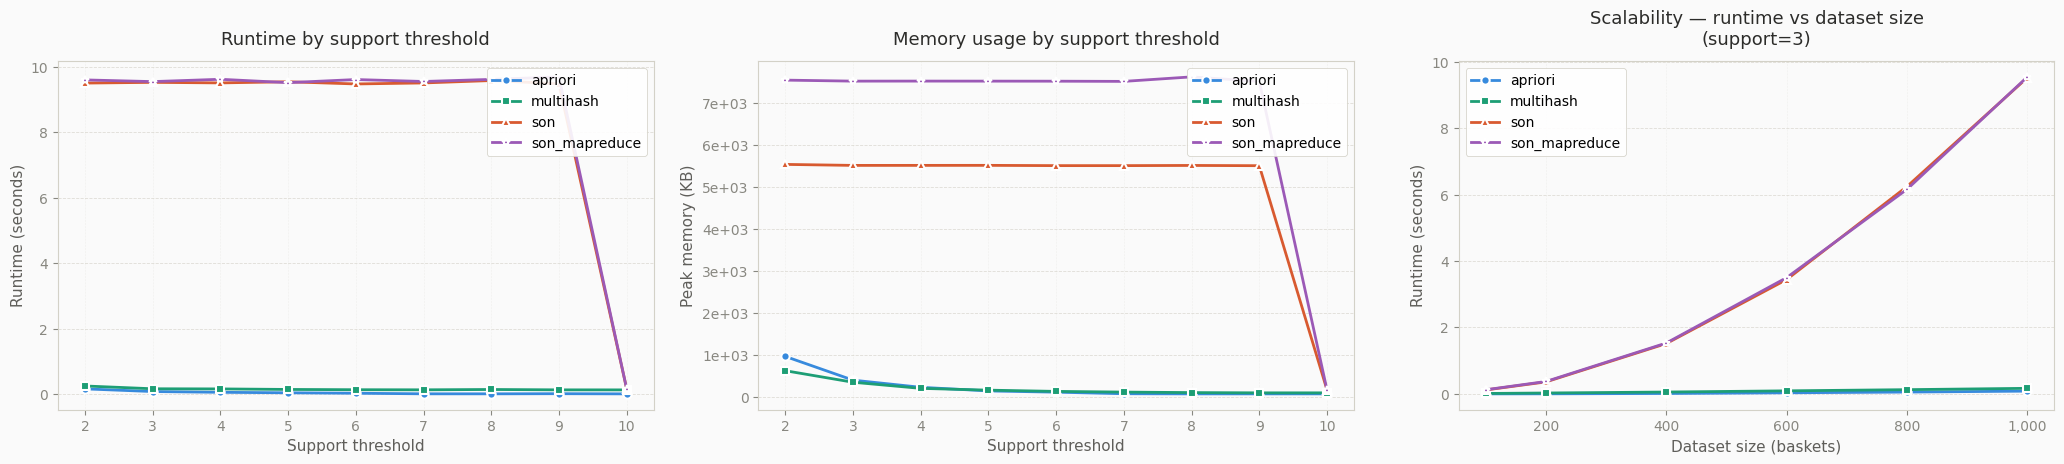

In [45]:
plot_benchmark(algorithm_evaluation)
